In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import mannwhitneyu as mwu
import ezodf

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from decimal import Decimal
from statannot import add_stat_annotation as asa
from tqdm import tqdm 
import io
from Bio.SeqUtils import molecular_weight as calculate_molecular_weight


from scipy.stats import normaltest
from scipy.stats import pearsonr

import sys
sys.path.insert(1, '../../scripts/') # comment out in python script
from utils.load_environmental_variables import *

In [4]:
# # parse and compile brenda
# enzymes = open(local_data_path + 'raw/brenda_download.txt').read().split(sep = 'RECOMMENDED_NAME')[2:]
# enzymes = [e for e in tqdm(enzymes) if 'Homo sapiens' in e and 'TURNOVER_NUMBER' in e]

# brenda = pd.DataFrame(columns = ['EC-class', 'Protein Number', 'Turnover (s^-1)'])

# error_lines = ['pH', 'hydrolysis', 'comparison', 'F152I,']
# brenda_idx = 0
# counter = 0
# for e in enzymes:
#     id_ = e[e.index('ID\t'):].split('\t')[1].split('\n')[0]
#     if 'PROTEIN' in e:
#         e = e.split('\n\n')
#         turnover = [i for i in e if 'TURNOVER_NUMBER' in i][0].split('\n')[1:] # get kcats
#         protein = [i for i in e if 'PROTEIN' in i][0].split('\n')
#         protein = [i.split('\t')[1].split(' Homo sapiens')[0] for i in protein if 'Homo sapiens' in i] # get protein no for human

#         # filter for turnover numbers of human proteins
#         turnover = [i for i in turnover if i.split('\t')[1].split(' ')[0] in protein]
#         if len(turnover)>0:
#             for i in turnover:
#                 comment = i.split('(')
#                 if len(comment)==1 or 'mutant' not in comment[1]: # filter out mutant proteins
#                     vals = i.split('\t')[1].split(' ')
#                     protein_no = vals[0]
#                     if protein_no in protein:
#                         if vals[1] not in error_lines and '-' not in vals[1]:
#                             turnover_ = float(vals[1])
#                         else: 
#                             if '-' in vals[1]: 
#                                 if len(vals[1].split('-')) > 2:
#                                     turnover_ = np.mean([float(i) for i in vals[1].split('-')]) # take avg when a range is provided
#                                 else:
#                                     pass # only one end of range provided
#                             elif vals[1] in error_lines:
#                                 pass # disregard the weird parsed line
#                         brenda.loc[brenda_idx, :] = [id_, protein_no, turnover_]
#                         brenda_idx += 1
    
# brenda['Turnover (s^-1)'] = brenda['Turnover (s^-1)'].astype(float)

# # take average across unique EC-class - Protein No pairs
# brenda = pd.DataFrame(brenda.groupby(['EC-class', 'Protein Number'])['Turnover (s^-1)'].mean())
# brenda.to_csv(local_data_path + 'processed/brenda_keff.csv')
brenda = pd.read_csv(local_data_path + 'processed/brenda_keff.csv', index_col = None)

In [5]:
brenda

,EC-class,Protein Number,Turnover (s^-1)
0,1.1.1.270,#11#,223.600000
1,1.1.1.284,#8#,3.835000
2,1.1.1.300,#19#,527.444444
3,1.1.1.31,#1#,0.410000
4,1.1.1.36,#2#,44.000000
...,...,...,...
254,6.2.1.15,#6#,1.560000
255,6.3.5.3,#6#,1.560000
256,6.3.5.5,#9#,1.924444
257,7.1.1.9,#13#,89.006667


In [6]:
turn_char = 'Turnover (s^-1)'
k_eff_median = brenda[turn_char].median()
print(k_eff_median)

3.983333333333333


/Users/joycebaghdassarian/opt/anaconda3/envs/human_me/lib/python3.6/site-packages/seaborn/distributions.py:2551 FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).


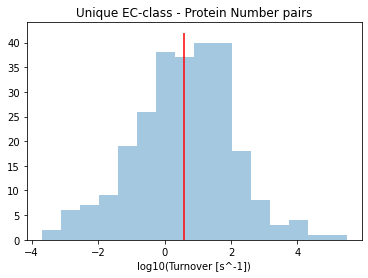

In [39]:
fig, ax = plt.subplots()
sns.distplot(np.log10(brenda[turn_char]), kde = False, ax = ax)
ax.set(xlabel = 'log10(Turnover [s^-1])', title = 'Unique EC-class - Protein Number pairs')
ylim = ax.get_ylim()
ax.vlines(np.log10(k_eff_median), ymin = ylim[0], ymax = ylim[1], color = 'red')
plt.savefig(local_data_path + 'figures/enzyme_turnover_distribution.png')
plt.savefig(local_data_path + 'figures/enzyme_turnover_distribution.pdf')

In [20]:
complex_df = pd.read_csv(local_data_path + 'interim/SASA_recon2_2.csv', index_col = 0)

/Users/joycebaghdassarian/opt/anaconda3/envs/human_me/lib/python3.6/site-packages/seaborn/distributions.py:2551 FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
/Users/joycebaghdassarian/opt/anaconda3/envs/human_me/lib/python3.6/site-packages/seaborn/distributions.py:2551 FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).


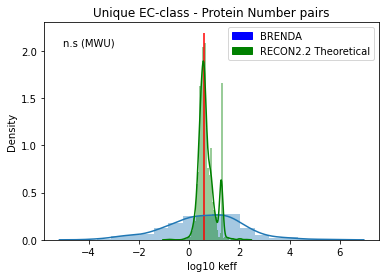

In [38]:
fig, ax = plt.subplots()

sns.distplot(np.log10(brenda[turn_char]), kde = True, ax = ax)
ax.set(xlabel = 'log10(Turnover [s^-1])', title = 'Unique EC-class - Protein Number pairs')
sns.distplot(np.log10(complex_df.drop_duplicates(subset = 'machinery').keff/3600), kde = True, ax = ax, color = 'green')

ylim = ax.get_ylim()
ax.vlines(np.log10(k_eff_median), ymin = ylim[0], ymax = ylim[1], color = 'red')

ax.set(xlabel = 'log10 keff')
ax.annotate('n.s (MWU)', xy = (-5,2.05))

blue_patch = mpatches.Patch(color='blue', label='BRENDA')
green_patch = mpatches.Patch(color='green', label='RECON2.2 Theoretical')
ax.legend(handles=[blue_patch, green_patch])

plt.savefig(local_data_path + 'figures/enzyme_turnover_distribution_v_theoretical.png')
plt.savefig(local_data_path + 'figures/enzyme_turnover_distribution_v_theoretical.pdf')